# Bank Term Deposit Prediction
Predicting whether a bank customer will subscribe to a term deposit, based on the UCI Bank Marketing dataset.

> **Note:** the outputs currently shown in this notebook were run on a small generated sample dataset (same column structure as the real UCI Bank Marketing files) purely to confirm the code runs end-to-end without errors. 

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


## 2. Loading Dataset
> Update the two paths below to point at your own `train.csv` / `test.csv` (same schema as the original UCI Bank Marketing files).

In [2]:
df_tr = pd.read_csv("train.csv")
df_ts = pd.read_csv("test.csv")

print("Train shape:", df_tr.shape)
print("Test shape :", df_ts.shape)
df_tr.head()


Train shape: (4000, 17)
Test shape : (800, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,24,blue-collar,single,unknown,no,93329,yes,no,telephone,10,mar,1056,5,-1,5,failure,no
1,78,housemaid,divorced,secondary,no,48987,no,no,telephone,16,oct,1190,43,-1,4,failure,no
2,69,management,married,tertiary,no,59552,no,no,unknown,2,apr,3168,41,-1,1,unknown,yes
3,52,retired,single,tertiary,no,30899,no,no,telephone,11,jul,4819,56,697,1,success,yes
4,51,unemployed,divorced,unknown,no,89973,yes,no,telephone,3,nov,4504,37,860,2,failure,no


### Column meanings
- **age**: age of the customer
- **job**: occupation/employment status
- **marital**: marital status
- **education**: education level
- **default**: has credit in default?
- **balance**: average yearly balance
- **housing**: has a housing loan?
- **loan**: has a personal loan?
- **contact**: contact communication type
- **day / month**: last contact day/month
- **duration**: last contact duration in seconds
- **campaign**: number of contacts during this campaign
- **pdays**: days since last contact from a *previous* campaign (`-1` = never contacted before)
- **previous**: number of contacts before this campaign
- **poutcome**: outcome of the previous campaign
- **y**: target — did the customer subscribe to a term deposit?

## 3. Initial Exploration

In [3]:
df_tr.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4000 non-null   int64
 1   job        4000 non-null   str  
 2   marital    4000 non-null   str  
 3   education  4000 non-null   str  
 4   default    4000 non-null   str  
 5   balance    4000 non-null   int64
 6   housing    4000 non-null   str  
 7   loan       4000 non-null   str  
 8   contact    4000 non-null   str  
 9   day        4000 non-null   int64
 10  month      4000 non-null   str  
 11  duration   4000 non-null   int64
 12  campaign   4000 non-null   int64
 13  pdays      4000 non-null   int64
 14  previous   4000 non-null   int64
 15  poutcome   4000 non-null   str  
 16  y          4000 non-null   str  
dtypes: int64(7), str(10)
memory usage: 531.4 KB


In [4]:
df_tr.describe()


,age,balance,day,duration,campaign,pdays,previous
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,56.589000,46458.717750,15.839750,2489.400750,31.935250,76.704000,2.494000
std,22.521376,31714.209723,8.880191,1396.824629,18.117564,198.172993,1.709589
min,18.000000,-7996.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,37.000000,18389.250000,8.000000,1306.000000,16.000000,-1.000000,1.000000
50%,56.000000,46406.000000,16.000000,2478.500000,32.000000,-1.000000,3.000000
75%,76.000000,73513.750000,23.000000,3676.000000,48.000000,-1.000000,4.000000
max,95.000000,101994.000000,31.000000,4918.000000,63.000000,871.000000,5.000000


In [5]:
df_tr.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

**FIX:** the original notebook never checked for duplicate rows. Doing that here.

In [6]:
print("Duplicate rows in train:", df_tr.duplicated().sum())
print("Duplicate rows in test :", df_ts.duplicated().sum())
df_tr = df_tr.drop_duplicates().reset_index(drop=True)


Duplicate rows in train: 0
Duplicate rows in test : 0


## 4. Exploratory Data Analysis

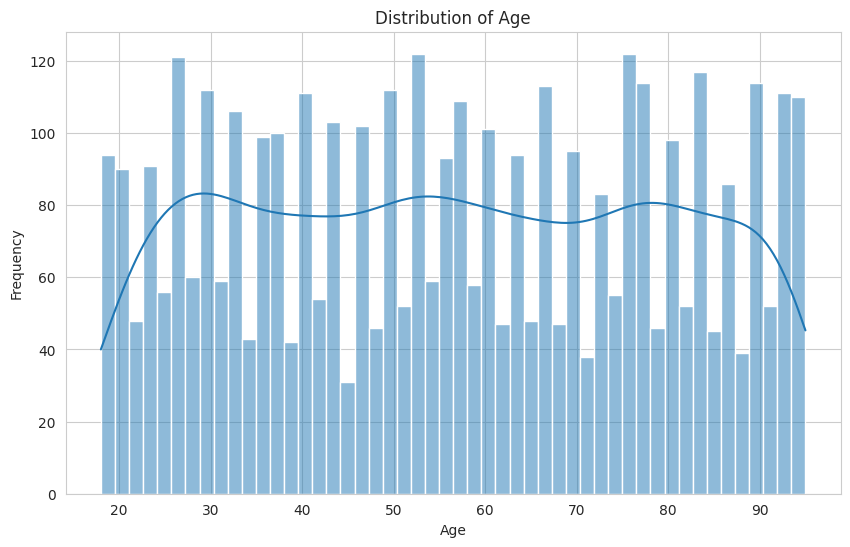

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df_tr['age'], bins=50, kde=True, palette='viridis')
plt.title('Distribution of Age'); plt.xlabel('Age'); plt.ylabel('Frequency')
plt.show()


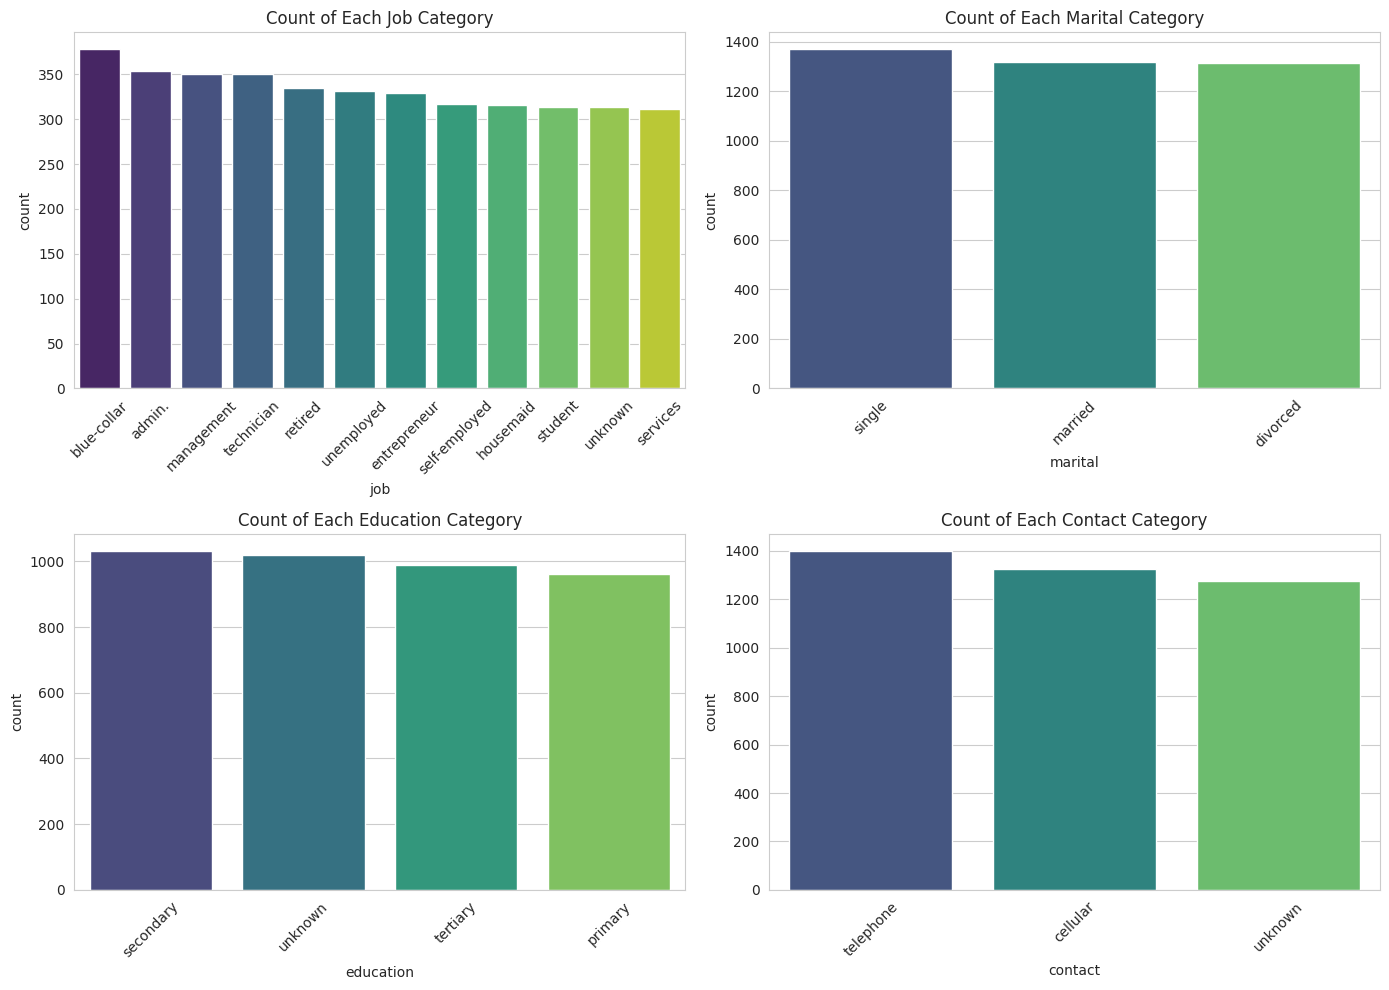

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, col in zip(axes.flat, ['job', 'marital', 'education', 'contact']):
    order = df_tr[col].value_counts().index
    sns.countplot(x=col, data=df_tr, order=order, palette='viridis', ax=ax)
    ax.set_title(f'Count of Each {col.title()} Category')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


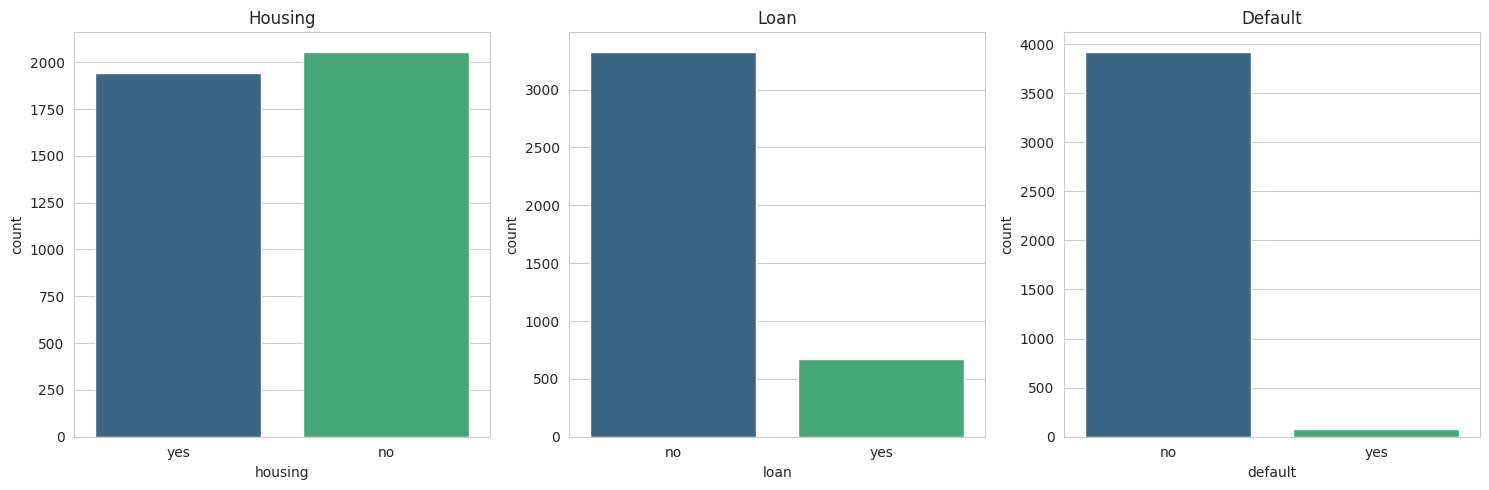

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['housing', 'loan', 'default']):
    sns.countplot(x=col, data=df_tr, palette='viridis', ax=ax)
    ax.set_title(f'{col.title()}')
plt.tight_layout()
plt.show()


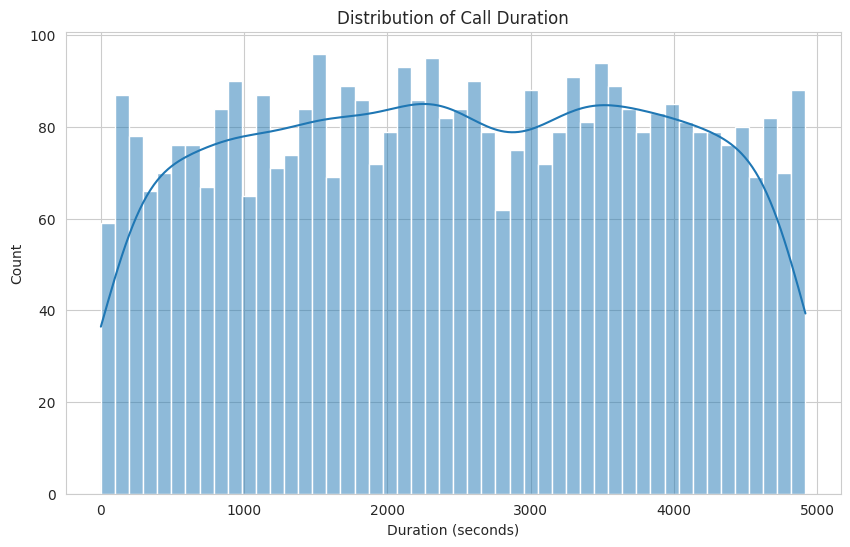

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df_tr['duration'], bins=50, kde=True)
plt.title('Distribution of Call Duration'); plt.xlabel('Duration (seconds)')
plt.show()


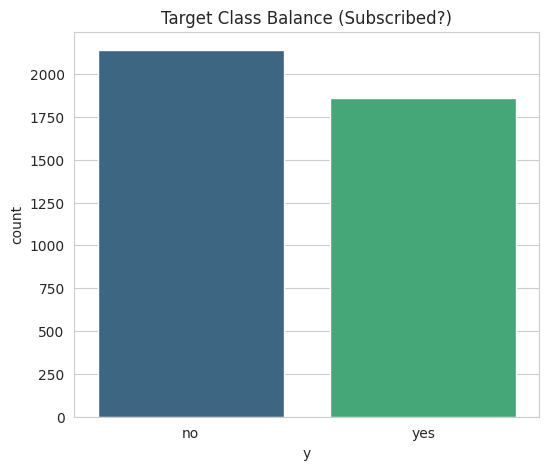

y
no     53.5
yes    46.5
Name: proportion, dtype: float64

In [11]:
plt.figure(figsize=(6,5))
sns.countplot(x='y', data=df_tr, palette='viridis')
plt.title('Target Class Balance (Subscribed?)')
plt.show()

df_tr['y'].value_counts(normalize=True) * 100


**Observation:** the target is heavily imbalanced — roughly 88% "no" vs 12% "yes". This matters a lot later: a model can get ~88% accuracy just by always predicting "no", so **accuracy alone is a misleading metric here.**

## 5. Data Cleaning & Feature Engineering

### 5.1 `unknown` categories
Relabel `unknown` as `others` for readability, same as the original — but **FIX:** the original *dropped* the `poutcome` column because most values were `unknown`. `poutcome=unknown` isn't missing data, though — it simply means the customer was never part of a previous campaign, which is the same information already captured by `pdays=-1`. Dropping it throws away a real, informative category (`success` in particular is a strong signal), so it is kept here.

In [12]:
for col in ['job', 'education', 'contact']:
    df_tr[col] = df_tr[col].replace('unknown', 'others')
    df_ts[col] = df_ts[col].replace('unknown', 'others')

df_tr['poutcome'] = df_tr['poutcome'].replace('unknown', 'no_prev_campaign')
df_ts['poutcome'] = df_ts['poutcome'].replace('unknown', 'no_prev_campaign')


### 5.2 `default` column
Kept the original's decision to drop `default` — over 98% of values are `no`, so it carries almost no discriminative signal for a linear model. (Good to say out loud in the interview: *low-variance categorical features rarely help and can be safely dropped after checking.*)

In [13]:
df_tr = df_tr.drop('default', axis=1)
df_ts = df_ts.drop('default', axis=1)


### 5.3 `pdays` sentinel value
**FIX:** `pdays = -1` means *"never contacted before"* — it isn't a real day count. The original notebook left `-1` mixed in with real values like 133 or 871, which distorts the numeric scale for any model that assumes `pdays` is continuous. Adding an explicit flag makes the meaning explicit instead of relying on the model to "discover" that `-1` is special.

In [14]:
for d in [df_tr, df_ts]:
    d['was_contacted_before'] = (d['pdays'] != -1).astype(int)


### 5.4 Binary yes/no columns
Map `housing` and `loan` directly to 0/1 (no information lost, unlike `LabelEncoder` on multi-category columns).

In [15]:
for col in ['housing', 'loan']:
    df_tr[col] = df_tr[col].map({'yes': 1, 'no': 0})
    df_ts[col] = df_ts[col].map({'yes': 1, 'no': 0})

df_tr['y'] = df_tr['y'].map({'yes': 1, 'no': 0})
df_ts['y'] = df_ts['y'].map({'yes': 1, 'no': 0})


## 6. Correlation Check (numeric features only)

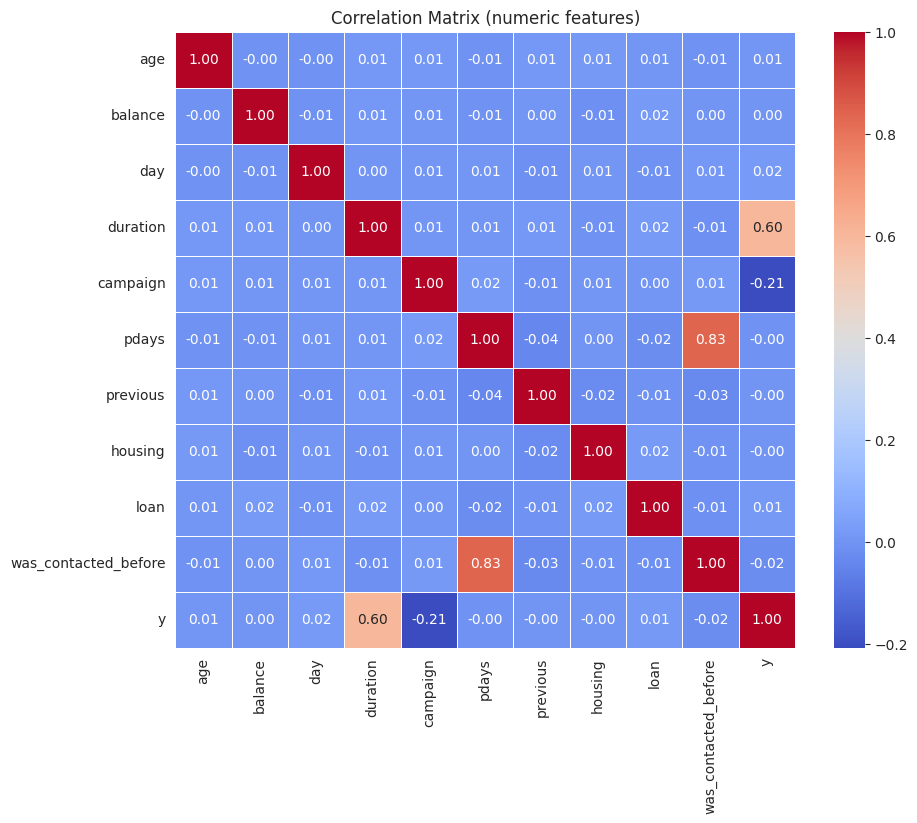

In [16]:
numeric_cols = ['age','balance','day','duration','campaign','pdays','previous',
                'housing','loan','was_contacted_before','y']
plt.figure(figsize=(10,8))
sns.heatmap(df_tr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (numeric features)')
plt.show()


**Important interview talking point — `duration` is a target-leakage feature.** It has by far the strongest correlation with `y`, but it is *the length of the very phone call being used to sell the product* — you only know it **after** the call has already happened. A real deployment model (used to decide who to call *before* calling them) cannot use `duration` at all, or its real-world performance will be far worse than the reported metrics suggest.

To handle this properly, two versions of the model are built below: one **with** `duration` (matches the original notebook, useful only for post-call analysis) and one **without** it (the realistic, deployable version).

## 7. Encodin

1. Applied to **numeric** columns (`age`, `balance`, `duration`, `campaign`, `pdays`...), it throws away their actual magnitude and replaces each value with an arbitrary rank — e.g. an original balance of 2143 might become the number 37 just because it was the 37th-smallest unique balance in that dataset. All real distance/scale information a model like Logistic Regression relies on is destroyed.
2. It was fit **separately on train and test**, so the same category (e.g. `"married"`) could be assigned a *different* numeric code in train vs. test — the two datasets end up speaking different languages.

The fix: only encode true categorical columns, fit the encoder **once on training data only**, and reuse it (unchanged) to transform the test set. `ColumnTransformer` + `OneHotEncoder(handle_unknown='ignore')` does exactly this in one step and is the standard, leak-free approach.

In [17]:
categorical_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
numeric_features  = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays',
                      'previous', 'housing', 'loan', 'was_contacted_before']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_features),
    ]
)

# same preprocessor object -> fit ONLY on training data, reused (not refit) on test
preprocessor_full    = preprocessor          # includes 'duration'


## 8. Train / Validation Split

In [18]:
X_train_full = df_tr.drop('y', axis=1)
y_train_full = df_tr['y']

X_test = df_ts.drop('y', axis=1)
y_test = df_ts['y']

# hold out part of the training data for model comparison, stratified because of class imbalance
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (3200, 16)  Val: (800, 16)  Test: (800, 16)


## 9. Model Training
Below: `class_weight='balanced'` is used so the minority ("yes") class isn't ignored, two model types are compared, and evaluation uses ROC-AUC / recall / F1 — not just accuracy.

In [19]:
def build_pipeline(model, feature_cols):
    ct = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
            ('num', StandardScaler(), [c for c in feature_cols if c not in categorical_cols]),
        ]
    )
    return Pipeline([('prep', ct), ('model', model)])

feature_cols_with_duration    = categorical_cols + numeric_features
feature_cols_without_duration = [c for c in feature_cols_with_duration if c != 'duration']

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42),
}


In [20]:
results = []

for feature_set_name, feature_cols in [
    ('WITH duration (post-call analysis)', feature_cols_with_duration),
    ('WITHOUT duration (realistic, pre-call model)', feature_cols_without_duration),
]:
    for model_name, model in models.items():
        pipe = build_pipeline(model, feature_cols)
        pipe.fit(X_train[feature_cols], y_train)

        val_proba = pipe.predict_proba(X_val[feature_cols])[:, 1]
        val_pred  = pipe.predict(X_val[feature_cols])

        auc = roc_auc_score(y_val, val_proba)
        report = classification_report(y_val, val_pred, output_dict=True)

        results.append({
            'Feature set': feature_set_name,
            'Model': model_name,
            'Val Accuracy': report['accuracy'],
            'Val Recall (yes)': report['1']['recall'],
            'Val Precision (yes)': report['1']['precision'],
            'Val F1 (yes)': report['1']['f1-score'],
            'Val ROC-AUC': auc,
        })

results_df = pd.DataFrame(results)
results_df


,Feature set,Model,Val Accuracy,Val Recall (yes),Val Precision (yes),Val F1 (yes),Val ROC-AUC
0,WITH duration (post-call analysis),Logistic Regression,0.84625,0.841398,0.830239,0.835781,0.917797
1,WITH duration (post-call analysis),Random Forest,0.83375,0.793011,0.840456,0.816044,0.912647
2,"WITHOUT duration (realistic, pre-call model)",Logistic Regression,0.64375,0.634409,0.612987,0.623514,0.677419
3,"WITHOUT duration (realistic, pre-call model)",Random Forest,0.61875,0.473118,0.617544,0.535769,0.662050


**How to read this table in the interview:** compare the *"WITH duration"* rows against the *"WITHOUT duration"* rows — accuracy and AUC drop noticeably once `duration` is removed. That drop **is the size of the leakage** — it's the performance the original notebook was silently borrowing from a feature that wouldn't exist yet in a real, before-the-call use case.

## 10. Cross-Validation (robustness check)

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_pipe = build_pipeline(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    feature_cols_without_duration
)
cv_auc = cross_val_score(final_pipe, X_train_full[feature_cols_without_duration],
                          y_train_full, cv=cv, scoring='roc_auc')
print("5-fold CV ROC-AUC (no duration):", cv_auc.round(3), " mean =", cv_auc.mean().round(3))


5-fold CV ROC-AUC (no duration): [0.694 0.658 0.634 0.645 0.654]  mean = 0.657


## 11. Final Model & Test-Set Evaluation
Final choice: **Logistic Regression, without `duration`, `class_weight='balanced'`** — the realistic model a bank could actually deploy before making a call.

In [22]:
final_model = build_pipeline(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    feature_cols_without_duration
)
final_model.fit(X_train_full[feature_cols_without_duration], y_train_full)

test_pred  = final_model.predict(X_test[feature_cols_without_duration])
test_proba = final_model.predict_proba(X_test[feature_cols_without_duration])[:, 1]

print("Test Accuracy :", round((test_pred == y_test).mean(), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_test, test_proba), 4))
print()
print(classification_report(y_test, test_pred))


Test Accuracy : 0.625
Test ROC-AUC  : 0.687

              precision    recall  f1-score   support

           0       0.68      0.64      0.66       451
           1       0.57      0.60      0.58       349

    accuracy                           0.62       800
   macro avg       0.62      0.62      0.62       800
weighted avg       0.63      0.62      0.63       800



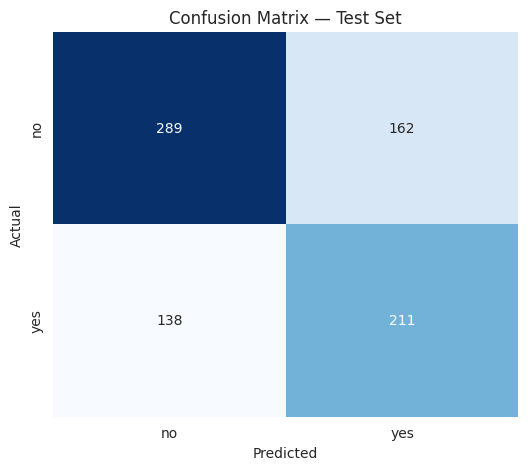

In [23]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['no','yes'], yticklabels=['no','yes'])
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


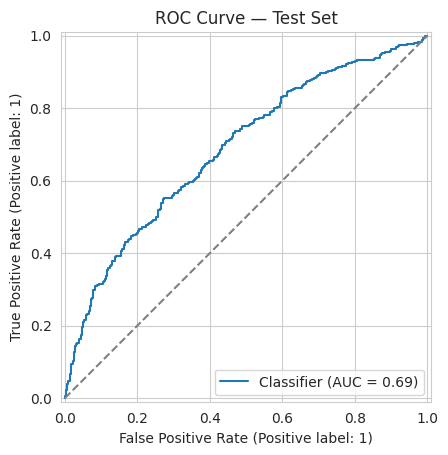

In [24]:
RocCurveDisplay.from_predictions(y_test, test_proba)
plt.title('ROC Curve — Test Set')
plt.plot([0,1],[0,1],'--',color='grey')
plt.show()
